# Wine quality prediction

In [3]:
import pandas as pd 
import numpy as np

# Data Preprocessing

In [4]:
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv', sep=';')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
df.shape

(1599, 12)

In [6]:
df['quality'].value_counts().sort_index()

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

In [7]:
df['quality_binary'] = (df['quality'] >= 6).astype(int)

In [8]:
df['quality_binary'].value_counts()

quality_binary
1    855
0    744
Name: count, dtype: int64

In [9]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_binary
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


In [10]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
quality_binary          0
dtype: int64

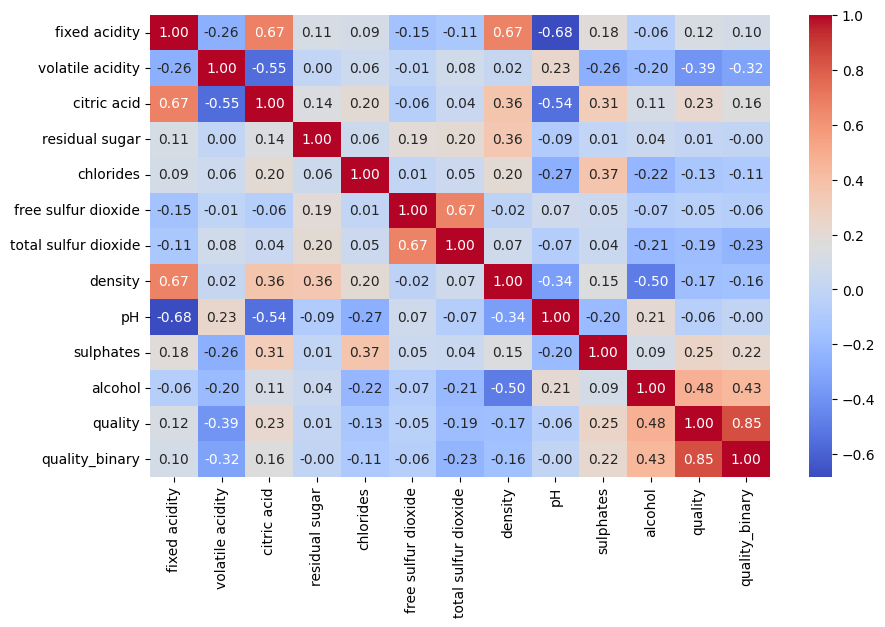

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt='.2f',cmap = 'coolwarm')
plt.show()


In [12]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Data splitting and scaling

In [15]:
features = ['fixed acidity','volatile acidity','citric acid','residual sugar','chlorides', 'free sulfur dioxide','total sulfur dioxide','density','pH','sulphates','alcohol']
X = df[features]
y = df['quality_binary']

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



# finding best parameters wuth gridsearchcv


In [16]:
param_grid = {
    'kernel' :['rbf', 'linear'],
    'C':[0.1,1,10,50,100]
}

grid_search = GridSearchCV(SVC(random_state=42), param_grid = param_grid, cv = 5, scoring='accuracy')
grid_search.fit(X_train_scaled,y_train)

print(f"Best Parameters SVC :{grid_search.best_params_}")
print(f"Best cross-validation score:{grid_search.best_score_}")

Best Parameters SVC :{'C': 10, 'kernel': 'rbf'}
Best cross-validation score:0.7717248774509804


In [17]:
model_svc = SVC(kernel='rbf',C=10, random_state=42)
model_svc.fit(X_train_scaled,y_train)

y_pred = model_svc.predict(X_test_scaled)

print(f"SVC accuracy score:{accuracy_score(y_test,y_pred)}")

SVC accuracy score:0.7625


In [20]:
param_grid = {
    'n_neighbors':list(range(1,30)),
    'weights': ['uniform', 'distance']
}

grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

print(f"Best parameters KNN: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_}")

Best parameters KNN: {'n_neighbors': 13, 'weights': 'distance'}
Best cross-validation score: 0.7967371323529411


In [22]:
model_knn = KNeighborsClassifier(n_neighbors=13,weights='distance')
model_knn.fit(X_train_scaled,y_train)

y_pred = model_knn.predict(X_test_scaled)

print(f"KNN accuracy:{accuracy_score(y_test,y_pred)}")

KNN accuracy:0.7875


In [27]:
param_grid = {
    'var_smoothing': np.logspace(-9, 3, 13)}

grid_search = GridSearchCV(GaussianNB(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

print(f"Best parameters NB : {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_}")

Best parameters NB : {'var_smoothing': np.float64(1.0)}
Best cross-validation score: 0.7310723039215686


In [28]:
model_nb = GaussianNB(var_smoothing=1.0)
model_nb.fit(X_train_scaled, y_train)

y_pred = model_nb.predict(X_test_scaled)

print(f"Niave Bayes Accuracy:{accuracy_score(y_test,y_pred)}")

Niave Bayes Accuracy:0.740625
